# Poison Experiment

## Imports

In [10]:
from binary_classifier import BinaryPoisonClassifier
import matplotlib.pyplot as plt
import pandas as pd

## Data Collection

In [14]:
poison_ratios = [0.01, 0.05, 0.1, 0.2, 0.5]
epochs_list = [5, 10, 15, 20]

loss_results = [[None for _ in poison_ratios] for _ in epochs_list]
report_results = [[None for _ in poison_ratios] for _ in epochs_list]
cm_results = [[None for _ in poison_ratios] for _ in epochs_list]

In [15]:
for i, epoch in enumerate(epochs_list):
    print(f"Running with {epoch} epochs")
    for j, poison_ratio in enumerate(poison_ratios):
        print(f"\tPoison ratio {poison_ratio}")
        classifier = BinaryPoisonClassifier(poison_ratio, epoch)

        losses = classifier.train_model()
        report = classifier.eval_model()

        loss_results[i][j] = losses
        report_results[i][j], cm_results[i][j] = report

Running with 5 epochs
	Poison ratio 0.01
	Poison ratio 0.05
	Poison ratio 0.1
	Poison ratio 0.2
	Poison ratio 0.5
Running with 10 epochs
	Poison ratio 0.01
	Poison ratio 0.05
	Poison ratio 0.1
	Poison ratio 0.2
	Poison ratio 0.5
Running with 15 epochs
	Poison ratio 0.01
	Poison ratio 0.05
	Poison ratio 0.1
	Poison ratio 0.2
	Poison ratio 0.5
Running with 20 epochs
	Poison ratio 0.01
	Poison ratio 0.05
	Poison ratio 0.1
	Poison ratio 0.2
	Poison ratio 0.5


## Plots and Tables

### Loss Control Charts

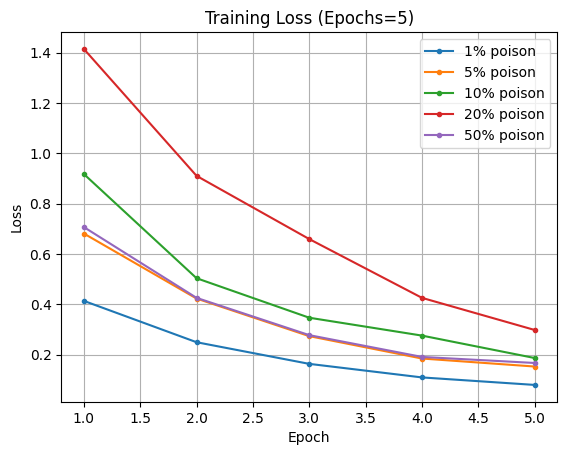

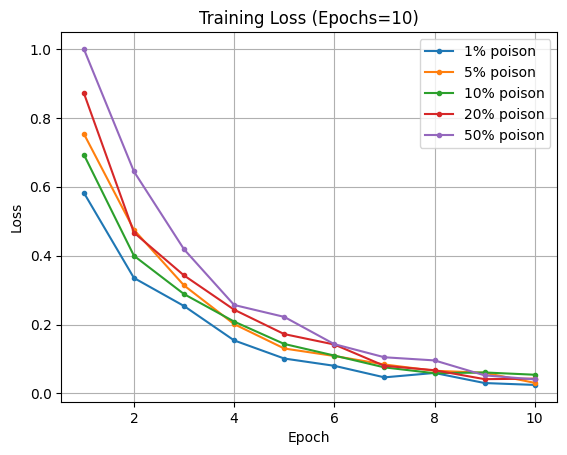

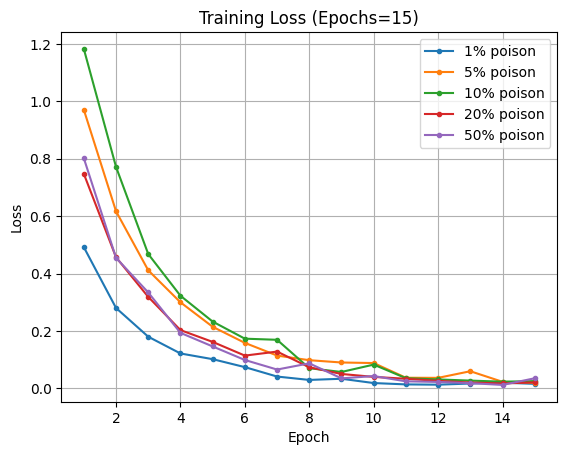

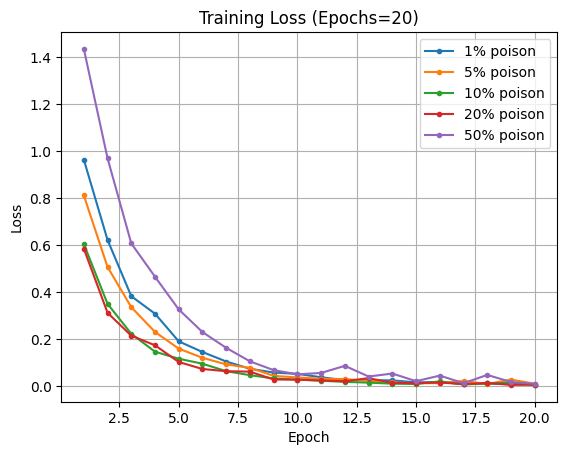

In [16]:
for i, epoch in enumerate(epochs_list):
    plt.figure()

    for j, ratio in enumerate(poison_ratios):
        losses = loss_results[i][j]
        plt.plot(range(1, len(losses)+1), losses, marker="o", markersize=3, label=f"{ratio*100:.0f}% poison")

    plt.title(f"Training Loss (Epochs={epoch})")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.show()

### Metric Tables

In [19]:
accuracy_table = []
precision_table = []
recall_table = []
f1_table = []

for i in range(len(epochs_list)):

    acc_row = []
    prec_row = []
    rec_row = []
    f1_row = []

    for j in range(len(poison_ratios)):

        report = report_results[i][j]

        acc_row.append(report["accuracy"])
        prec_row.append(report["Poison"]["precision"])
        rec_row.append(report["Poison"]["recall"])
        f1_row.append(report["Poison"]["f1-score"])

    accuracy_table.append(acc_row)
    precision_table.append(prec_row)
    recall_table.append(rec_row)
    f1_table.append(f1_row)

In [20]:
columns = [f"{int(r*100)}%" for r in poison_ratios]
index = [f"{e} epochs" for e in epochs_list]

accuracy_df = pd.DataFrame(accuracy_table, index=index, columns=columns)
precision_df = pd.DataFrame(precision_table, index=index, columns=columns)
recall_df = pd.DataFrame(recall_table, index=index, columns=columns)
f1_df = pd.DataFrame(f1_table, index=index, columns=columns)

print("Accuracy")
print(accuracy_df)

print("\nPrecision")
print(precision_df)

print("\nRecall")
print(recall_df)

print("\nF1 Score")
print(f1_df)

Accuracy
             1%    5%   10%   20%   50%
5 epochs   0.85  0.85  0.85  0.75  0.85
10 epochs  0.85  0.85  0.85  0.80  0.85
15 epochs  0.85  0.80  0.85  0.85  0.85
20 epochs  0.85  0.85  0.85  0.85  0.85

Precision
            1%   5%  10%  20%       50%
5 epochs   0.0  0.0  0.0  0.0  0.000000
10 epochs  0.0  0.0  0.0  0.0  0.000000
15 epochs  0.0  0.0  0.0  0.0  0.000000
20 epochs  0.0  0.0  0.0  0.0  0.333333

Recall
            1%   5%  10%  20%  50%
5 epochs   0.0  0.0  0.0  0.0  0.0
10 epochs  0.0  0.0  0.0  0.0  0.0
15 epochs  0.0  0.0  0.0  0.0  0.0
20 epochs  0.0  0.0  0.0  0.0  0.5

F1 Score
            1%   5%  10%  20%  50%
5 epochs   0.0  0.0  0.0  0.0  0.0
10 epochs  0.0  0.0  0.0  0.0  0.0
15 epochs  0.0  0.0  0.0  0.0  0.0
20 epochs  0.0  0.0  0.0  0.0  0.4
